# Approaches to find candidate genes (genomic approach)

In [1]:
# open vcf file
import numpy as np
import cyvcf2
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

SAMPLE   = "SBC10"
VCF_PATH = "../results/sift4g/SBC10.private.sift4g.vcf.gz"

## prepare dataframe

In [2]:
ANN_FIELDS = [
    "ann_allele", "ann_effect", "ann_impact", "ann_gene_name", "ann_gene_id",
    "ann_feature_type", "ann_feature_id", "ann_biotype", "ann_rank",
    "ann_hgvs_c", "ann_hgvs_p", "ann_cdna_pos", "ann_cds_pos", "ann_aa_pos",
    "ann_distance", "ann_extra",
]

SIFT_FIELDS = [
    "sift_allele", "sift_transcript", "sift_gene_id", "sift_gene_name",
    "sift_region", "sift_variant_type", "sift_aa_change", "sift_aa_pos",
    "sift_score", "sift_median", "sift_num_seqs", "sift_allele_type",
    "sift_prediction",
]

# SIFT4G writes DELETERIOUS (score < 0.05) or TOLERATED; NA means non-coding
_SIFT_PRIORITY = {"DELETERIOUS": 0, "TOLERATED": 1}


def _parse_ann(raw: str) -> list[dict]:
    records = []
    for entry in raw.split(","):
        parts = entry.split("|")
        parts += [""] * (len(ANN_FIELDS) - len(parts))
        records.append(dict(zip(ANN_FIELDS, parts[:len(ANN_FIELDS)])))
    return records


def _parse_siftinfo(raw: str) -> dict:
    """Returns (allele, transcript) -> best SIFT record.

    Both SnpEff and SIFT4G are built from NCBIv3 GFF, so ann_feature_id and
    sift_transcript share the same XM_* namespace and can be joined directly.
    SIFT4G annotates one representative transcript per gene; unmatched ANN
    transcript rows receive no SIFT columns.
    """
    by_key: dict[tuple, dict] = {}
    for entry in raw.split(","):
        parts = entry.split("|")
        parts += [""] * (len(SIFT_FIELDS) - len(parts))
        d = dict(zip(SIFT_FIELDS, parts[:len(SIFT_FIELDS)]))
        key = (d["sift_allele"], d["sift_transcript"])
        pred = d.get("sift_prediction", "")
        current = by_key.get(key)
        if current is None or _SIFT_PRIORITY.get(pred, 99) < _SIFT_PRIORITY.get(current.get("sift_prediction", ""), 99):
            by_key[key] = d
    return by_key


def parse_vcf(vcf_path: str) -> pd.DataFrame:
    """
    Parse a SIFT4G+SnpEff annotated VCF into a DataFrame.
    One row per ANN annotation entry; SIFT columns joined by (allele, transcript).
    Gene identity is kept as two columns straight from the VCF: ann_gene_id
    (SnpEff) and sift_gene_id (SIFT4G).
    """
    vcf = cyvcf2.VCF(vcf_path)
    rows = []
    for variant in vcf:
        gt_arr = variant.genotypes[0]
        sep = "|" if gt_arr[2] else "/"
        base = {
            "chrom":  variant.CHROM,
            "pos":    variant.POS,
            "ref":    variant.REF,
            "alt":    ",".join(variant.ALT),
            "qual":   variant.QUAL,
            "filter": variant.FILTER,
            "gt":     f"{gt_arr[0]}{sep}{gt_arr[1]}",
        }

        ann_raw  = variant.INFO.get("ANN")
        sift_raw = variant.INFO.get("SIFTINFO")
        annotations = _parse_ann(ann_raw)       if ann_raw  else [{}]
        sift_by_key = _parse_siftinfo(sift_raw) if sift_raw else {}

        for ann in annotations:
            key  = (ann.get("ann_allele", ""), ann.get("ann_feature_id", ""))
            sift = sift_by_key.get(key, {})
            rows.append({**base, **ann, **sift})

    df = pd.DataFrame(rows)
    df["sift_score"] = pd.to_numeric(df.get("sift_score"), errors="coerce")
    df["sift_score_c"] = 1 - df["sift_score"]
    return df


In [3]:
df = parse_vcf(VCF_PATH)
df

,chrom,pos,ref,alt,qual,filter,gt,ann_allele,ann_effect,ann_impact,...,sift_region,sift_variant_type,sift_aa_change,sift_aa_pos,sift_score,sift_median,sift_num_seqs,sift_allele_type,sift_prediction,sift_score_c
0,NC_012870.2,1619,G,A,54.540001,None,1|0,A,upstream_gene_variant,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NC_012870.2,1619,G,A,54.540001,None,1|0,A,intergenic_region,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NC_012870.2,5784,A,"AGG,AG",25.700001,None,1/2,AG,downstream_gene_variant,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NC_012870.2,5784,A,"AGG,AG",25.700001,None,1/2,AGG,downstream_gene_variant,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NC_012870.2,5784,A,"AGG,AG",25.700001,None,1/2,AG,intergenic_region,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
933920,NC_012879.2,61233644,A,AG,35.650002,None,1/1,AG,upstream_gene_variant,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
933921,NC_012879.2,61233644,A,AG,35.650002,None,1/1,AG,intergenic_region,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
933922,NC_012879.2,61233676,G,GT,32.020000,None,1/1,GT,upstream_gene_variant,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
933923,NC_012879.2,61233676,G,GT,32.020000,None,1/1,GT,upstream_gene_variant,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df['ann_biotype'].value_counts()

ann_biotype
protein_coding    416125
                  408191
pseudogene        109609
Name: count, dtype: int64

In [8]:
# Can "keep the protein_coding transcript" uniquely resolve a multi-transcript gene?
# Only if every gene has EXACTLY ONE protein_coding transcript. Count distinct
# protein_coding transcripts per gene; any gene with >1 means the biotype filter
# alone still leaves multiple rows and won't fully collapse that gene.
prot_cod = df[df["ann_biotype"] == "protein_coding"]
pc_tx_per_gene = prot_cod.groupby("ann_gene_id")["ann_feature_id"].nunique()

n_multi = int((pc_tx_per_gene > 1).sum())
print(f"genes with a protein_coding annotation : {len(pc_tx_per_gene):,}")
print(f"  exactly 1 protein_coding transcript  : {int((pc_tx_per_gene == 1).sum()):,}")
print(f"  more than 1 (NOT resolved by biotype): {n_multi:,}")
print(f"max protein_coding transcripts in a gene: {pc_tx_per_gene.max()}")

if n_multi:
    print("\nbiotype == 'protein_coding' does NOT fully resolve; top offenders:")
    print(pc_tx_per_gene.sort_values(ascending=False).head(10))
else:
    print("\nEvery gene has a single protein_coding transcript -> biotype filter is sufficient.")

genes with a protein_coding annotation : 19,309
  exactly 1 protein_coding transcript  : 15,343
  more than 1 (NOT resolved by biotype): 3,966
max protein_coding transcripts in a gene: 33

biotype == 'protein_coding' does NOT fully resolve; top offenders:
ann_gene_id
LOC110431236    33
LOC8075269      33
LOC8073351      32
LOC8084814      25
LOC8078323      22
LOC8080836      21
LOC8069083      20
LOC110433886    20
LOC8075242      18
LOC8076898      18
Name: ann_feature_id, dtype: int64


In [4]:
# distribution of c sift score
# I need the number to score non-HIGH non-SIFT-scores-having annotated variant sites
# print(pd.to_numeric(df["sift_score_c"], errors='coerce').describe())
# print("\n")
for impact in df["ann_impact"].unique():
    print(f"{impact}\n{pd.to_numeric(df[df['ann_impact'] == impact]['sift_score_c'], errors='coerce').mean()}\n")

MODIFIER
nan

MODERATE
0.6311843507383164

HIGH
0.9326315789473684

LOW
0.12894495412844037



## implement scoring of each row in the dataframe

In [5]:
# scoring criteria based on the mean of sift score complement of each impact tier
MODERATE_SCORE = 0.631184
LOW_SCORE = 0.128945
MODIFIER_SCORE = 0.0

def scoring(df):
    impact_default = {
        "MODERATE": MODERATE_SCORE,
        "LOW":      LOW_SCORE,
        "MODIFIER": MODIFIER_SCORE,
        }
    score = df["ann_impact"].map(impact_default)                      # default by impact (NaN if unknown)
    score = score.mask(df["sift_score_c"].notna(), df["sift_score_c"])  # use real SIFT score where present
    score = score.mask(df["ann_impact"] == "HIGH", 1.0)              # HIGH always tops out
    df["score"] = score
    return df

In [6]:
df_scored = scoring(df)
df_scored

,chrom,pos,ref,alt,qual,filter,gt,ann_allele,ann_effect,ann_impact,...,sift_variant_type,sift_aa_change,sift_aa_pos,sift_score,sift_median,sift_num_seqs,sift_allele_type,sift_prediction,sift_score_c,score
0,NC_012870.2,1619,G,A,54.540001,None,1|0,A,upstream_gene_variant,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1,NC_012870.2,1619,G,A,54.540001,None,1|0,A,intergenic_region,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2,NC_012870.2,5784,A,"AGG,AG",25.700001,None,1/2,AG,downstream_gene_variant,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3,NC_012870.2,5784,A,"AGG,AG",25.700001,None,1/2,AGG,downstream_gene_variant,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
4,NC_012870.2,5784,A,"AGG,AG",25.700001,None,1/2,AG,intergenic_region,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
933920,NC_012879.2,61233644,A,AG,35.650002,None,1/1,AG,upstream_gene_variant,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
933921,NC_012879.2,61233644,A,AG,35.650002,None,1/1,AG,intergenic_region,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
933922,NC_012879.2,61233676,G,GT,32.020000,None,1/1,GT,upstream_gene_variant,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
933923,NC_012879.2,61233676,G,GT,32.020000,None,1/1,GT,upstream_gene_variant,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


In [7]:
tx_per_gene = (df_scored[df_scored["ann_feature_type"] == "transcript"]
                .groupby("ann_gene_id")["ann_feature_id"].nunique()
                .sort_values(ascending=False))
tx_per_gene.head(10)          # LOC8059218 = 50, …
df_scored.loc[df_scored["ann_gene_id"] == "LOC8059546", "ann_feature_id"].unique()

array(['XM_021458661.1', 'XM_021458660.1'], dtype=object)

In [8]:
df_scored[df_scored['ann_gene_id'] == 'LOC8059218'].to_csv("sample_mul_trx.csv")

In [9]:
df_scored["score"].describe()

count    933925.000000
mean          0.010975
std           0.089421
min           0.000000
25%           0.000000
50%           0.000000
75%           0.000000
max           1.000000
Name: score, dtype: float64

In [10]:
def plot_kdeplot(df, title, ax=None, clip=None):
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(8, 5))

    sns.kdeplot(
        data=df,
        x="score",
        fill=True,
        clip=clip,        # None -> auto range (sum / normalized); pass [0, 1] for row / gene-MAX
        cut=0,
        bw_adjust=1.0,
        ax=ax,
    )

    ax.set_title(f"Scores distribution on {title} level")
    ax.set_xlabel("Score")
    ax.set_yscale("log")
    ax.set_ylabel("Density (log scale)")

    if own_fig:
        fig.tight_layout()
        plt.show()
    return ax

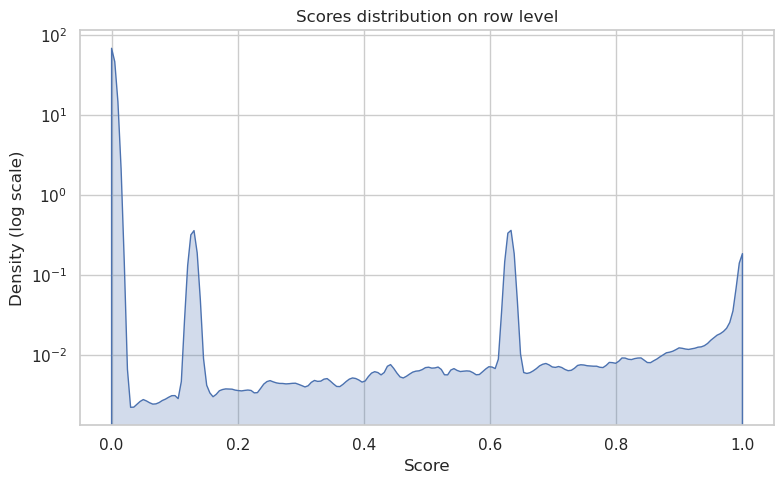

<Axes: title={'center': 'Scores distribution on row level'}, xlabel='Score', ylabel='Density (log scale)'>

In [11]:
# base model plotting using .plot method
# df_scored["score"].plot.kde(ind=np.linspace(0, 1.0, 1000))

# using seaborn, logarithmic
plot_kdeplot(df_scored, "row")

In [12]:
df_scored[df_scored['ann_gene_id'] == 'LOC8080657']

,chrom,pos,ref,alt,qual,filter,gt,ann_allele,ann_effect,ann_impact,...,sift_variant_type,sift_aa_change,sift_aa_pos,sift_score,sift_median,sift_num_seqs,sift_allele_type,sift_prediction,sift_score_c,score
643333,NC_012876.2,58505890,A,AG,48.549999,None,1/1,AG,upstream_gene_variant,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
643335,NC_012876.2,58509035,CCTTATGTCTTTA,C,33.340000,None,1/1,C,downstream_gene_variant,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


## merging rows onto gene level

### MAX approach

In [13]:
# maximum approach: one row per gene = its worst (highest-score) variant
def merge_to_gene_max(df_scored: pd.DataFrame, gene_key: str = "ann_gene_id") -> pd.DataFrame:
    """Collapse variant/transcript rows to one row per gene.

    Maximum / worst-variant approach: each gene keeps the single annotation
    with the highest ``score``, so the gene-level risk equals its most
    damaging variant. The full worst-variant row is retained (effect, impact,
    SIFT, position) for context. Rows with no gene id are dropped.
    """
    scored = df_scored[df_scored[gene_key].fillna("").ne("")]
    idx = scored.groupby(gene_key)["score"].idxmax()       # worst variant per gene
    return (
        scored.loc[idx]
        .sort_values("score", ascending=False)
        .reset_index(drop=True)
    )


df_scored_gene = merge_to_gene_max(df_scored)
df_scored_gene

,chrom,pos,ref,alt,qual,filter,gt,ann_allele,ann_effect,ann_impact,...,sift_variant_type,sift_aa_change,sift_aa_pos,sift_score,sift_median,sift_num_seqs,sift_allele_type,sift_prediction,sift_score_c,score
0,NC_012871.2,7260824,G,C,33.700001,None,1/1,C,missense_variant,MODERATE,...,NONSYNONYMOUS,A/G,193,0.0,4.32,1,novel,DELETERIOUS (*WARNING! Low confidence),1.0,1.0
1,NC_012875.2,58046000,GCAACGGCGTTTGTTTTGGGTTCTTTTGATTT,G,34.060001,None,1/1,G,frameshift_variant&splice_region_variant,HIGH,...,FRAMESHIFT DELETION,NA/NA,NA,NaN,NA,NA,NA,NA,NaN,1.0
2,NC_012877.2,59800110,T,TAG,56.779999,None,1/1,TAG,frameshift_variant,HIGH,...,FRAMESHIFT INSERTION,NA/NA,NA,NaN,NA,NA,NA,NA,NaN,1.0
3,NC_012875.2,48250602,A,AACCTG,35.759998,None,1/1,AACCTG,frameshift_variant,HIGH,...,FRAMESHIFT INSERTION,NA/NA,NA,NaN,NA,NA,NA,NA,NaN,1.0
4,NC_012879.2,53830826,TACTGGTCCGAAAGGGC,T,45.580002,None,1/1,T,frameshift_variant,HIGH,...,FRAMESHIFT DELETION,NA/NA,NA,NaN,NA,NA,NA,NA,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36907,NC_012873.2,14947759,TGATGGTGGTGGG,T,37.029999,None,1/1,T,downstream_gene_variant,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
36908,NC_012875.2,54521227,T,C,25.500000,None,1/1,C,downstream_gene_variant,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
36909,NC_012875.2,54521227,T,C,25.500000,None,1/1,C,intergenic_region,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
36910,NC_012875.2,54659215,C,CT,22.490000,None,0/1,CT,upstream_gene_variant,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


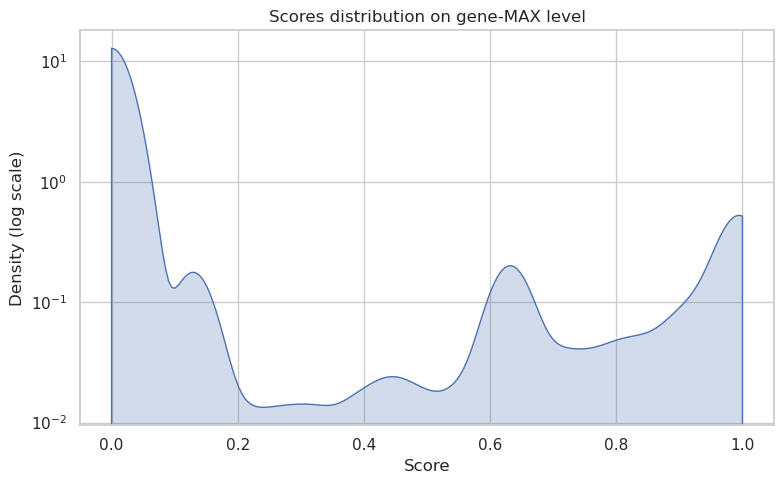

<Axes: title={'center': 'Scores distribution on gene-MAX level'}, xlabel='Score', ylabel='Density (log scale)'>

In [14]:
plot_kdeplot(df_scored_gene, "gene-MAX")

## SUM approach

In [15]:
# sum approach: one row per gene = sum of all its variant/transcript scores
def merge_to_gene_sum(df_scored: pd.DataFrame, gene_key: str = "ann_gene_id") -> pd.DataFrame:
    """Collapse variant/transcript rows to one row per gene by summing scores.

    Sum approach: a gene's risk is the total of every annotation score it
    carries, so it rewards genes hit by many and/or more damaging variants
    (unlike the max approach, which only looks at the single worst variant).
    n_rows is kept alongside for context. Rows with no gene id are dropped.

    Note: SnpEff emits one row per transcript, so multi-transcript genes
    accumulate more rows; the sum reflects that transcript multiplicity.
    """
    scored = df_scored[df_scored[gene_key].fillna("").ne("")]
    return (
        scored.groupby(gene_key)
        .agg(
            score=("score", "sum"),
            n_rows=("score", "size"),
            ann_gene_name=("ann_gene_name", "first"),
        )
        .reset_index()
        .sort_values("score", ascending=False)
        .reset_index(drop=True)
    )


df_scored_gene_sum = merge_to_gene_sum(df_scored)
df_scored_gene_sum

,ann_gene_id,score,n_rows,ann_gene_name
0,LOC110431053,462.077566,2190,LOC110431053
1,LOC8074840,321.178748,1864,LOC8074840
2,LOC8070962,184.120718,819,LOC8070962
3,LOC8061721,164.383565,592,LOC8061721
4,LOC8073632,122.711911,364,LOC8073632
...,...,...,...,...
36907,LOC8060383,0.000000,12,LOC8060383
36908,LOC8060438,0.000000,1,LOC8060438
36909,LOC8060438-LOC110436500,0.000000,1,LOC8060438-LOC110436500
36910,LOC8060446,0.000000,1,LOC8060446


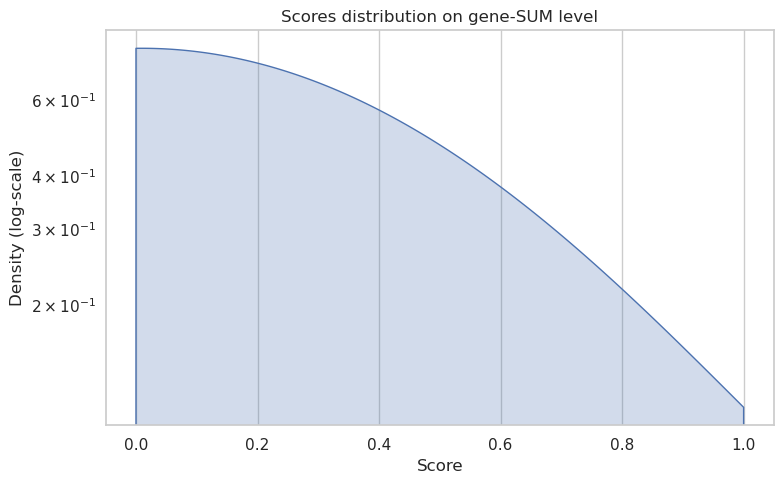

In [16]:
# plot_kdeplot(df_scored_gene_sum, "gene-SUM")

fig, ax = plt.subplots(figsize=(8, 5))

sns.kdeplot(
    data=df_scored_gene_sum,
    x="score",
    fill=True,
    clip=[0, 1],
    cut=0,
    bw_adjust=1.0,
    ax=ax,
)

ax.set_title(f"Scores distribution on gene-SUM level")
ax.set_xlabel("Score")

ax.set_yscale("log")
ax.set_ylabel("Density (log-scale)")
fig.tight_layout()
plt.show()

### Gene length (from GFF3)

In [17]:
# gene length (genomic span, bp) keyed by LOC gene id, from the NCBI GFF3
import gzip, re

GFF_PATH = "../resources/annot/GCF_000003195.3_Sorghum_bicolor_NCBIv3_genomic.gff.gz"


def load_gene_length(gff_path: str) -> dict:
    """Map gene Name (LOC...) -> genomic length in bp, from an NCBI GFF3.

    Parses 'gene' and 'pseudogene' features; length = end - start + 1 (genomic
    span, introns + UTRs). Keyed by the Name= attribute, which equals
    ann_gene_id for LOC-named genes. tRNA (SnpEff '..._N') and combo/intergenic
    keys won't match -> those genes get NaN length downstream.
    """
    lengths = {}
    opener = gzip.open if gff_path.endswith(".gz") else open
    with opener(gff_path, "rt") as fh:
        for line in fh:
            if line.startswith("#"):
                continue
            f = line.rstrip("\n").split("\t")
            if len(f) < 9 or f[2] not in ("gene", "pseudogene"):
                continue
            m = re.search(r"Name=([^;]+)", f[8])
            if m:
                lengths[m.group(1)] = int(f[4]) - int(f[3]) + 1
    return lengths


gene_length = load_gene_length(GFF_PATH)
print(f"{len(gene_length):,} genes;  LOC8061396 -> {gene_length.get('LOC8061396')} bp")

32,458 genes;  LOC8061396 -> 3176 bp


### SUM normalized by gene length

In [18]:
# sum approach normalized by genomic gene length (score per kb)
def merge_to_gene_sum_norm(df_scored: pd.DataFrame, gene_length: dict,
                           gene_key: str = "ann_gene_id", per_kb: bool = True) -> pd.DataFrame:
    """SUM gene score divided by genomic gene length (default: score per kb).

    Reuses merge_to_gene_sum, then normalizes. The normalized value is named
    ``score`` (so plot_kdeplot works); the raw sum is kept as score_raw.
    Genes with no length match (tRNA '_N', combo keys) -> NaN score.

    Note: length-normalization corrects for gene size only, NOT the SUM
    method's transcript-multiplicity inflation (see n_rows).
    """
    g = merge_to_gene_sum(df_scored, gene_key).rename(columns={"score": "score_raw"})
    g["gene_length"] = g[gene_key].map(gene_length)
    g["score"] = g["score_raw"] / g["gene_length"] * (1000 if per_kb else 1)
    return g.sort_values("score", ascending=False).reset_index(drop=True)


df_scored_gene_sum_norm = merge_to_gene_sum_norm(df_scored, gene_length)
df_scored_gene_sum_norm

,ann_gene_id,score_raw,n_rows,ann_gene_name,gene_length,score
0,LOC110431053,462.077566,2190,LOC110431053,6582.0,70.203216
1,LOC8081127,26.464736,101,LOC8081127,618.0,42.823197
2,LOC8073632,122.711911,364,LOC8073632,3246.0,37.804039
3,LOC8061721,164.383565,592,LOC8061721,5094.0,32.270036
4,LOC8070962,184.120718,819,LOC8070962,5724.0,32.166443
...,...,...,...,...,...,...
36907,LOC8060446-LOC8057701,0.000000,1,LOC8060446-LOC8057701,NaN,NaN
36908,LOC8060379-LOC8060380,0.000000,301,LOC8060379-LOC8060380,NaN,NaN
36909,LOC8060380-LOC8060381,0.000000,22,LOC8060380-LOC8060381,NaN,NaN
36910,LOC8060438-LOC110436500,0.000000,1,LOC8060438-LOC110436500,NaN,NaN


In [21]:
df_scored_gene_sum_norm[0:10]

,ann_gene_id,score_raw,n_rows,ann_gene_name,gene_length,score
0,LOC110431053,462.077566,2190,LOC110431053,6582.0,70.203216
1,LOC8081127,26.464736,101,LOC8081127,618.0,42.823197
2,LOC8073632,122.711911,364,LOC8073632,3246.0,37.804039
3,LOC8061721,164.383565,592,LOC8061721,5094.0,32.270036
4,LOC8070962,184.120718,819,LOC8070962,5724.0,32.166443
5,LOC8066370,58.893024,152,LOC8066370,1857.0,31.714068
6,LOC8069102,105.649074,351,LOC8069102,3483.0,30.332780
7,LOC8072467,44.803552,186,LOC8072467,1688.0,26.542389
8,LOC8066889,9.750000,22,LOC8066889,439.0,22.209567
9,LOC8069091,87.143552,273,LOC8069091,4023.0,21.661335


### MAX normalized by gene length

In [19]:
# max approach normalized by genomic gene length (score per kb)
def merge_to_gene_max_norm(df_scored: pd.DataFrame, gene_length: dict,
                           gene_key: str = "ann_gene_id", per_kb: bool = True) -> pd.DataFrame:
    """MAX gene score divided by genomic gene length (default: score per kb).

    Reuses merge_to_gene_max (full worst-variant row), then normalizes. The
    normalized value is named ``score`` (so plot_kdeplot works); the raw max is
    kept as score_raw. Genes with no length match (tRNA '_N', combo keys) ->
    NaN score.

    Note: max / length mostly re-ranks equal-max genes inversely by length.
    """
    g = merge_to_gene_max(df_scored, gene_key).rename(columns={"score": "score_raw"})
    g["gene_length"] = g[gene_key].map(gene_length)
    g["score"] = g["score_raw"] / g["gene_length"] * (1000 if per_kb else 1)
    return g.sort_values("score", ascending=False).reset_index(drop=True)


df_scored_gene_max_norm = merge_to_gene_max_norm(df_scored, gene_length)
df_scored_gene_max_norm

,chrom,pos,ref,alt,qual,filter,gt,ann_allele,ann_effect,ann_impact,...,sift_aa_pos,sift_score,sift_median,sift_num_seqs,sift_allele_type,sift_prediction,sift_score_c,score_raw,gene_length,score
0,NC_012871.2,50561358,C,CT,50.770000,None,1/1,CT,frameshift_variant,HIGH,...,NA,NaN,NA,NA,NA,NA,NaN,1.0,126.0,7.936508
1,NC_012876.2,15598868,T,C,32.009998,None,0|1,C,stop_lost&splice_region_variant,HIGH,...,101,NaN,NA,NA,novel,NA,NaN,1.0,303.0,3.300330
2,NC_012872.2,5054576,G,C,58.000000,None,1/1,C,missense_variant,MODERATE,...,28,0.0,4.32,171,novel,DELETERIOUS (*WARNING! Low confidence),1.0,1.0,318.0,3.144654
3,NC_012874.2,10160493,G,GC,39.070000,None,1|0,GC,frameshift_variant,HIGH,...,NA,NaN,NA,NA,NA,NA,NaN,1.0,324.0,3.086420
4,NC_012871.2,15327838,T,TC,35.430000,None,0|1,TC,frameshift_variant&stop_lost&splice_region_var...,HIGH,...,NA,NaN,NA,NA,NA,NA,NaN,1.0,330.0,3.030303
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36907,NC_012875.2,54659215,C,CT,22.490000,None,0/1,CT,intergenic_region,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
36908,NC_012873.2,14796054,T,A,35.020000,None,1/1,A,intergenic_region,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
36909,NC_012873.2,14912613,C,CAT,22.080000,None,1/1,CAT,intergenic_region,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN
36910,NC_012875.2,54521227,T,C,25.500000,None,1/1,C,intergenic_region,MODIFIER,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN


## Compare all four approaches

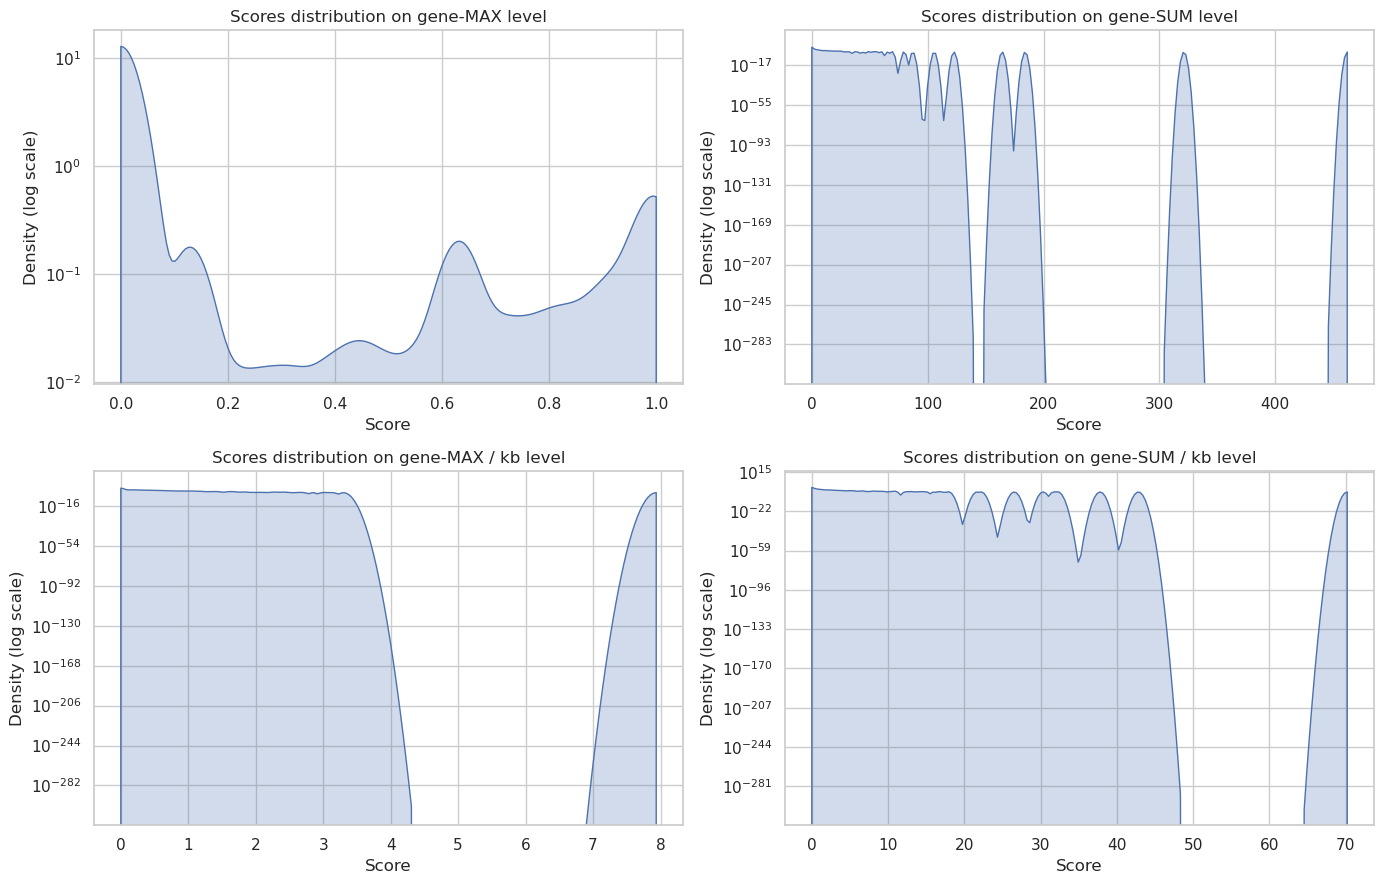

In [20]:
# compare all four gene-level approaches (each panel auto-scaled to its own range)
panels = [
    (df_scored_gene,          "gene-MAX"),
    (df_scored_gene_sum,      "gene-SUM"),
    (df_scored_gene_max_norm, "gene-MAX / kb"),
    (df_scored_gene_sum_norm, "gene-SUM / kb"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
for (d, t), ax in zip(panels, axes.flat):
    plot_kdeplot(d, t, ax=ax)
fig.tight_layout()
plt.show()